# Team 4 Final Project  
# US Accidents 데이터를 활용한 교통사고 심각도 분류

## 프로젝트 개요

본 노트북은 Kaggle의 **US Accidents (2016–2023)** 데이터를 활용하여 교통사고의 심각도(`Severity`)를 예측하는 지도학습 기반 다중분류 프로젝트이다.

예측 대상인 `Severity`는 1, 2, 3, 4의 네 개 클래스로 구성되어 있다.  
본 프로젝트에서는 사고 발생 시점에서 활용 가능하다고 판단되는 시간, 위치, 기상, 도로환경 변수를 사용하여 사고 심각도를 예측한다.

## 과제 요구사항 반영 사항

- 교통 분야와 관련된 지도학습 문제 정의
- Kaggle 공개 데이터 사용
- 전처리 후 피처 10개 이상, 인스턴스 1,000개 이상
- 기계학습 알고리즘 2개 이상 비교
- 동일한 train / validation / test 분할 사용
- 동일한 평가 지표 사용
- 시각화 8개 이상 포함
- Baseline 모델과 비교 모델 포함
- 하이퍼파라미터 변경 효과 분석
- 변수 중요도 분석
- 선택 과제용 간단한 딥러닝 모델 추가 실험
- 결과표와 그래프를 `outputs/`, `figures/` 폴더에 저장

## 0. 기본 설정

분석에 필요한 라이브러리를 불러오고, 실험 재현성을 위해 `RANDOM_STATE`를 고정한다.  
또한 결과표와 그래프를 저장하기 위해 `outputs/`, `figures/` 폴더를 생성한다.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

import sklearn
print("scikit-learn:", sklearn.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.2.3
numpy: 1.26.4
scikit-learn: 1.8.0


## 1. Google Drive 연결

Colab에서 Google Drive에 저장된 CSV 파일을 읽기 위해 Drive를 연결한다.  
로컬 환경에서 실행하는 경우 이 셀은 건너뛰고, 아래의 `file_path`만 로컬 경로로 수정하면 된다.

In [5]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print("Google Drive 연결을 건너뜁니다. 로컬 실행 시 file_path를 직접 설정하세요.")
    print(e)


Google Drive 연결을 건너뜁니다. 로컬 실행 시 file_path를 직접 설정하세요.
No module named 'google.colab'


## 2. 데이터 경로 및 데이터셋 정보

아래 `file_path`는 실제 CSV 파일 위치에 맞게 수정해야 한다.  
원본 데이터는 용량이 크기 때문에 GitHub 저장소에는 업로드하지 않고, Kaggle에서 직접 다운로드하여 사용한다.

In [6]:
# 데이터 파일 경로 설정
# Colab 사용 예시: file_path = "/content/drive/MyDrive/US_Accidents_March23.csv"
# 로컬 실행 예시: file_path = "data/US_Accidents_March23.csv"
# 본인 환경에 맞게 아래 경로만 수정하면 된다.
file_path = "C:/Users/USER/Desktop/기계학습 프로젝트/US_Accidents_March23.csv"

# 원본 CSV는 용량이 크므로 GitHub에는 업로드하지 않는다.
dataset_info = {
    "dataset_name": "US Accidents (2016-2023)",
    "source_url": "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents",
    "download_date": "2026-05-24",
    "license": "CC BY-NC-SA 4.0",
    "target": "Severity"
}

dataset_info


{'dataset_name': 'US Accidents (2016-2023)',
 'source_url': 'https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents',
 'download_date': '2026-05-24',
 'license': 'CC BY-NC-SA 4.0',
 'target': 'Severity'}

## 3. 사용할 변수 선택

원본 데이터에는 많은 변수가 포함되어 있지만, 본 프로젝트에서는 사고 발생 시점에서 활용 가능하다고 판단되는 변수만 사용한다.

### 사용한 변수 그룹

- 시간 변수: `Start_Time`
- 위치 변수: 위도, 경도, 주, 카운티, 도시, 시간대
- 기상 변수: 온도, 체감온도, 습도, 기압, 가시거리, 풍속, 강수량, 날씨 상태
- 주야간 변수: 일출/일몰, 박명 정보
- 도로환경 변수: 교차부, 신호등, 횡단시설, 정지표지, 철도 등

### 제외한 대표 변수

- `End_Time`: 사고 종료 이후 확정되는 정보
- `Distance(mi)`: 사고 영향 구간을 직접 반영할 가능성이 있는 정보
- `End_Lat`, `End_Lng`: 사고 종료 지점 정보
- `Description`: 자연어 텍스트 변수로 별도 NLP 처리가 필요함
- `ID`, `Street`, `Zipcode`: 식별자 성격 또는 고유값이 많은 변수

이러한 변수들은 성능을 높일 수는 있지만, 사고 발생 시점의 예측 문제에서는 정보 누수 가능성이 있으므로 제외하였다.

In [7]:
use_cols = [
    "Severity",
    "Start_Time",

    "Start_Lat",
    "Start_Lng",
    "State",
    "County",
    "City",
    "Timezone",

    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",

    "Wind_Direction",
    "Weather_Condition",

    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",

    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop"
]

print("선택한 원본 변수 수:", len(use_cols))

선택한 원본 변수 수: 34


## 4. 데이터 불러오기

`usecols`를 사용하여 필요한 열만 불러온다.  
데이터 규모가 크기 때문에 필요한 열만 읽으면 메모리 사용량을 줄일 수 있다.

In [8]:
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"CSV 파일을 찾을 수 없습니다: {file_path}"
        "file_path를 본인 환경에 맞게 수정하세요."
        "예시: Colab은 '/content/drive/MyDrive/US_Accidents_March23.csv', "
        "로컬은 'data/US_Accidents_March23.csv'"
    )

df = pd.read_csv(file_path, usecols=use_cols, low_memory=False)

print("원본 데이터 크기:", df.shape)
display(df.head())


원본 데이터 크기: (7728394, 34)


,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,Montgomery,OH,US/Eastern,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,US/Eastern,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,Clermont,OH,US/Eastern,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,Montgomery,OH,US/Eastern,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,Montgomery,OH,US/Eastern,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


## 5. 데이터 기본 정보 확인

데이터의 자료형, 결측치 여부, 수치형 변수의 기본 통계를 확인한다.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 34 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Severity               int64  
 1   Start_Time             object 
 2   Start_Lat              float64
 3   Start_Lng              float64
 4   City                   object 
 5   County                 object 
 6   State                  object 
 7   Timezone               object 
 8   Temperature(F)         float64
 9   Wind_Chill(F)          float64
 10  Humidity(%)            float64
 11  Pressure(in)           float64
 12  Visibility(mi)         float64
 13  Wind_Direction         object 
 14  Wind_Speed(mph)        float64
 15  Precipitation(in)      float64
 16  Weather_Condition      object 
 17  Amenity                bool   
 18  Bump                   bool   
 19  Crossing               bool   
 20  Give_Way               bool   
 21  Junction               bool   
 22  No_Exit           

In [10]:
display(df.describe())

,Severity,Start_Lat,Start_Lng,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


## 6. 타깃 변수 분포 확인

예측 대상은 `Severity`이다.  
클래스 분포가 불균형하면 Accuracy만으로 모델 성능을 평가하기 어렵기 때문에 먼저 타깃 분포를 확인한다.

In [11]:
# matplotlib 한글 폰트 설정
# Colab과 Windows 로컬 환경을 구분하여 실행한다.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if IN_COLAB:
    # Colab에서는 NanumGothic 설치 후 사용
    !apt-get -qq install fonts-nanum
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"
    else:
        print("NanumGothic 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
else:
    # Windows 로컬 Jupyter/VS Code에서는 보통 Malgun Gothic 사용
    if platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
print("한글 폰트 설정 완료")


한글 폰트 설정 완료


표 1. 원본 데이터의 Severity 클래스별 건수와 비율


,count,ratio
Severity,,
1,67366,0.008717
2,6156981,0.796670
3,1299337,0.168125
4,204710,0.026488


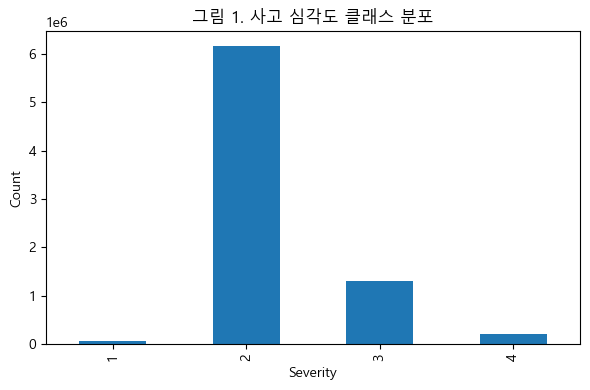

In [12]:
severity_count = df["Severity"].value_counts().sort_index()
severity_ratio = df["Severity"].value_counts(normalize=True).sort_index()

severity_df = pd.DataFrame({
    "count": severity_count,
    "ratio": severity_ratio
})

print("표 1. 원본 데이터의 Severity 클래스별 건수와 비율")
display(severity_df)

plt.figure(figsize=(6, 4))
severity_count.plot(kind="bar")
plt.title("그림 1. 사고 심각도 클래스 분포")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig01_severity_distribution.png", dpi=200)
plt.show()

## 7. 층화 샘플링

원본 데이터가 매우 크기 때문에 일부 표본을 사용한다.  
단순 랜덤 샘플링을 하면 클래스 비율이 달라질 수 있으므로, `stratify=df["Severity"]`를 사용하여 Severity 비율을 유지한다.

샘플링 후 데이터 크기: (100000, 34)
표 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교


,original_ratio,sample_ratio
Severity,,
1,0.008717,0.00872
2,0.796670,0.79667
3,0.168125,0.16812
4,0.026488,0.02649


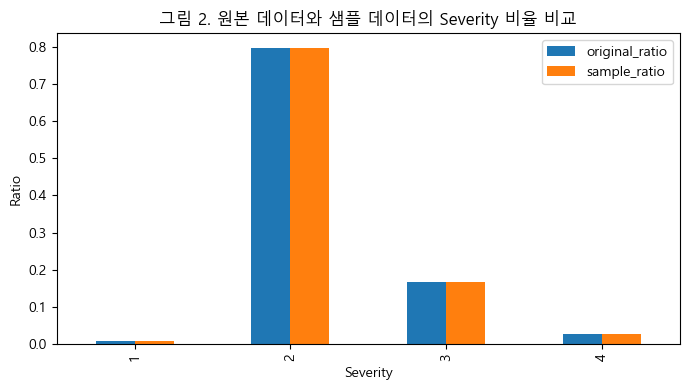

In [13]:
if len(df) > SAMPLE_SIZE:
    sampled_df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=df["Severity"]
    )
else:
    sampled_df = df.copy()

sampled_df = sampled_df.reset_index(drop=True)

print("샘플링 후 데이터 크기:", sampled_df.shape)

sample_ratio_df = pd.DataFrame({
    "original_ratio": df["Severity"].value_counts(normalize=True).sort_index(),
    "sample_ratio": sampled_df["Severity"].value_counts(normalize=True).sort_index()
})

print("표 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교")
display(sample_ratio_df)

sample_ratio_df.plot(kind="bar", figsize=(7, 4))
plt.title("그림 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교")
plt.xlabel("Severity")
plt.ylabel("Ratio")
plt.tight_layout()
plt.savefig("figures/fig02_original_sample_ratio.png", dpi=200)
plt.show()

## 8. 시간 변수 생성

`Start_Time`에서 연도, 월, 요일, 시간 변수를 생성한다.

In [14]:
data = sampled_df.copy()

# pandas 버전 호환성을 위해 format="mixed"를 사용하지 않고 자동 파싱한다.
data["Start_Time"] = pd.to_datetime(data["Start_Time"], errors="coerce")

data["Year"] = data["Start_Time"].dt.year
data["Month"] = data["Start_Time"].dt.month
data["DayOfWeek"] = data["Start_Time"].dt.dayofweek
data["Hour"] = data["Start_Time"].dt.hour

data = data.drop(columns=["Start_Time"])

display(data[["Year", "Month", "DayOfWeek", "Hour"]].head())


,Year,Month,DayOfWeek,Hour
0,2018.0,2.0,0.0,12.0
1,2019.0,9.0,4.0,9.0
2,2020.0,3.0,3.0,16.0
3,2021.0,9.0,6.0,14.0
4,2020.0,6.0,5.0,15.0


## 9. 날씨 변수 단순화

`Weather_Condition`은 세부 범주가 많다.  
차원이 지나치게 커지는 것을 줄이기 위해 비슷한 날씨를 묶어 `Weather_Group` 변수를 생성한다.

In [15]:
def weather_group(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).lower()

    if "clear" in x or "fair" in x:
        return "Clear"
    elif "cloud" in x or "overcast" in x:
        return "Cloudy"
    elif "rain" in x or "drizzle" in x or "shower" in x:
        return "Rain"
    elif "snow" in x or "sleet" in x or "ice" in x:
        return "Snow"
    elif "fog" in x or "mist" in x or "haze" in x:
        return "Fog"
    else:
        return "Other"


data["Weather_Group"] = data["Weather_Condition"].apply(weather_group)
data = data.drop(columns=["Weather_Condition"])

display(data["Weather_Group"].value_counts())

Weather_Group
Clear      44293
Cloudy     40657
Rain        6948
Fog         2543
Unknown     2272
Snow        2066
Other       1221
Name: count, dtype: int64

## 10. 범주가 많은 변수 정리

`City`, `County`는 고유값이 많기 때문에 상위 30개 값만 유지하고 나머지는 `Other`로 통합한다.

In [16]:
def keep_top_values(series, top_n=30):
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), "Other")


for col in ["City", "County"]:
    data[col] = data[col].fillna("Unknown")
    data[col] = keep_top_values(data[col], top_n=30)

print("City 고유값 수:", data["City"].nunique())
print("County 고유값 수:", data["County"].nunique())

City 고유값 수: 31
County 고유값 수: 31


## 11. 강수량 결측 여부 변수 추가

`Precipitation(in)`은 결측치가 많을 수 있다.  
강수량 값이 결측인지 여부 자체도 의미가 있을 수 있으므로 `Precipitation_NA` 변수를 추가한다.

In [17]:
data["Precipitation_NA"] = data["Precipitation(in)"].isna().astype(int)

display(data[["Precipitation(in)", "Precipitation_NA"]].head())

,Precipitation(in),Precipitation_NA
0,NaN,1
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


## 12. Boolean 변수 변환

도로환경 변수 중 True/False 값으로 되어 있는 변수는 0/1로 변환한다.

In [18]:
bool_cols = data.select_dtypes(include=["bool"]).columns.tolist()

for col in bool_cols:
    data[col] = data[col].astype(int)

print("0/1로 변환한 Boolean 변수:", bool_cols)

0/1로 변환한 Boolean 변수: ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']


## 13. 결측치 비율 확인

결측치 처리는 train / validation / test 분할 이후에 진행한다.  
이 단계에서는 결측치가 많은 변수를 확인한다.

표 3. 전처리 후 변수별 결측치 비율 상위 20개


Precipitation(in)        0.28598
Wind_Chill(F)            0.25881
Year                     0.09662
Hour                     0.09662
DayOfWeek                0.09662
Month                    0.09662
Wind_Speed(mph)          0.07424
Visibility(mi)           0.02320
Humidity(%)              0.02305
Wind_Direction           0.02286
Temperature(F)           0.02173
Pressure(in)             0.01876
Sunrise_Sunset           0.00323
Astronomical_Twilight    0.00323
Nautical_Twilight        0.00323
Civil_Twilight           0.00323
Timezone                 0.00092
Turning_Loop             0.00000
Traffic_Signal           0.00000
Severity                 0.00000
dtype: float64

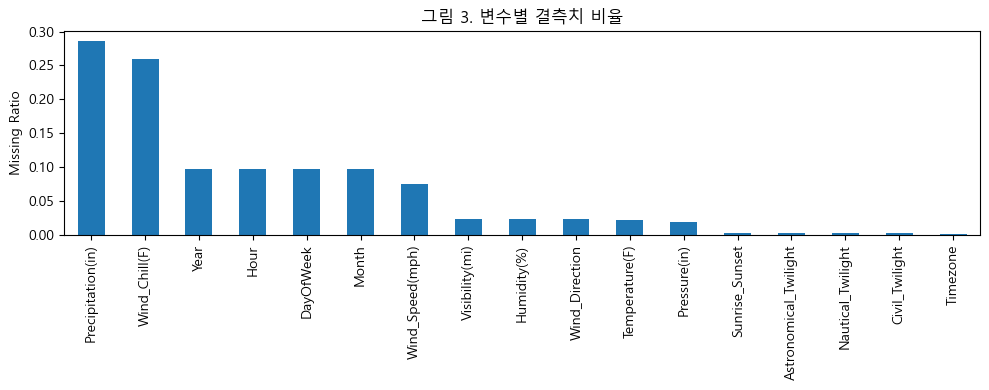

In [19]:
missing_ratio = data.isnull().mean().sort_values(ascending=False)

print("표 3. 전처리 후 변수별 결측치 비율 상위 20개")
display(missing_ratio.head(20))

plt.figure(figsize=(10, 4))
missing_ratio[missing_ratio > 0].plot(kind="bar")
plt.title("그림 3. 변수별 결측치 비율")
plt.ylabel("Missing Ratio")
plt.tight_layout()
plt.savefig("figures/fig03_missing_ratio.png", dpi=200)
plt.show()

## 14. 탐색적 데이터 분석(EDA)

과제 요구사항에 맞추어 8개 이상의 그래프를 포함한다.  
아래 그래프들은 사고 시간, 월, 날씨, 신호등, 교차부, 가시거리, 지역 분포, 도로환경 변수의 특성을 확인하기 위한 것이다.

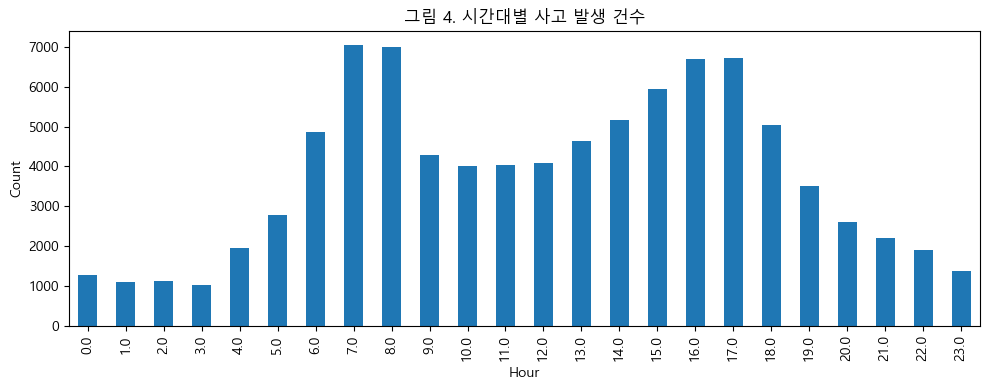

In [20]:
plt.figure(figsize=(10, 4))
data["Hour"].value_counts().sort_index().plot(kind="bar")
plt.title("그림 4. 시간대별 사고 발생 건수")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig04_accidents_by_hour.png", dpi=200)
plt.show()

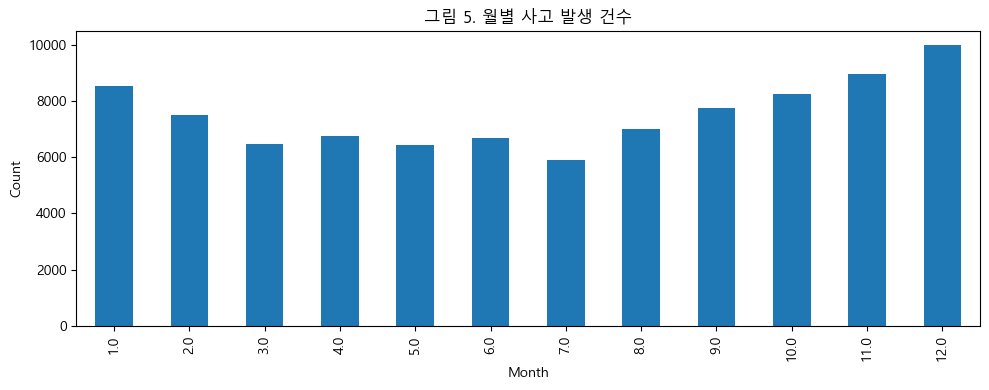

In [21]:
plt.figure(figsize=(10, 4))
data["Month"].value_counts().sort_index().plot(kind="bar")
plt.title("그림 5. 월별 사고 발생 건수")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig05_accidents_by_month.png", dpi=200)
plt.show()

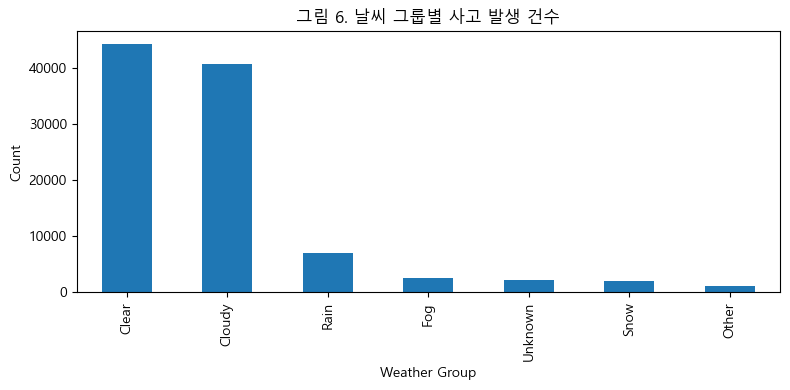

In [22]:
plt.figure(figsize=(8, 4))
data["Weather_Group"].value_counts().plot(kind="bar")
plt.title("그림 6. 날씨 그룹별 사고 발생 건수")
plt.xlabel("Weather Group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig06_accidents_by_weather.png", dpi=200)
plt.show()

표 4. 날씨 그룹별 Severity 비율


Severity,1,2,3,4
Weather_Group,,,,
Clear,0.010814,0.819317,0.144425,0.025444
Cloudy,0.008018,0.774602,0.191578,0.025801
Fog,0.002359,0.839953,0.137633,0.020055
Other,0.010647,0.826372,0.135135,0.027846
Rain,0.005901,0.763817,0.202073,0.028210
Snow,0.000484,0.799129,0.154889,0.045499
Unknown,0.002641,0.783891,0.170335,0.043134


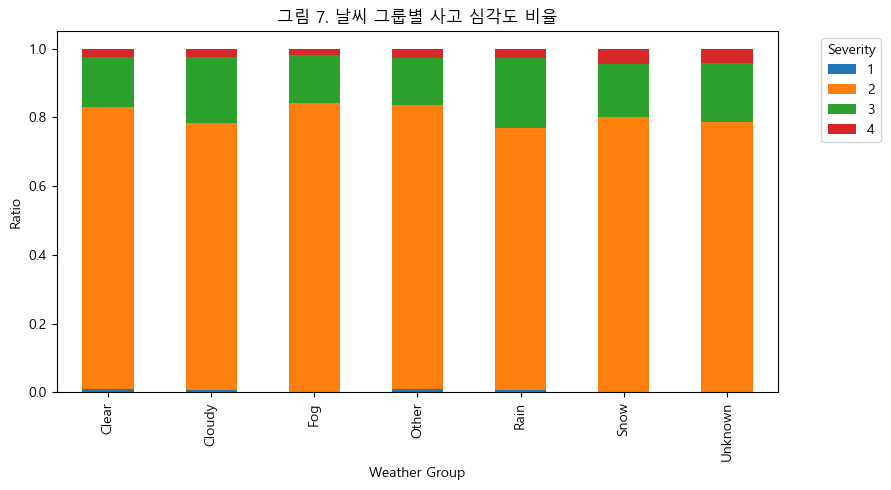

In [23]:
weather_severity = pd.crosstab(data["Weather_Group"], data["Severity"], normalize="index")
print("표 4. 날씨 그룹별 Severity 비율")
display(weather_severity)

weather_severity.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("그림 7. 날씨 그룹별 사고 심각도 비율")
plt.xlabel("Weather Group")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig07_weather_severity_ratio.png", dpi=200)
plt.show()

표 5. 신호등 여부별 Severity 비율


Severity,1,2,3,4
Traffic_Signal,,,,
0,0.006347,0.781893,0.183909,0.027851
1,0.022422,0.881994,0.076954,0.018629


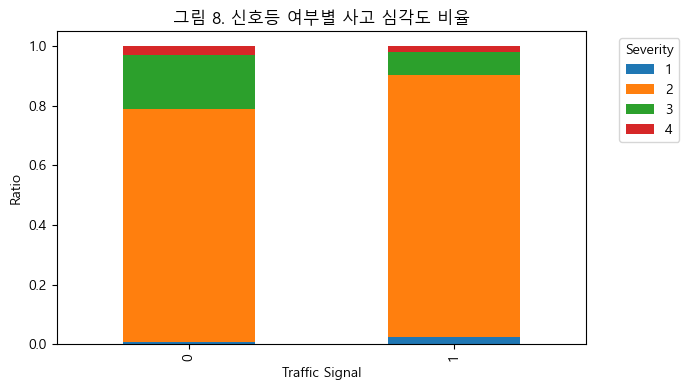

In [24]:
signal_severity = pd.crosstab(data["Traffic_Signal"], data["Severity"], normalize="index")
print("표 5. 신호등 여부별 Severity 비율")
display(signal_severity)

signal_severity.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("그림 8. 신호등 여부별 사고 심각도 비율")
plt.xlabel("Traffic Signal")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig08_signal_severity_ratio.png", dpi=200)
plt.show()

표 6. 교차부 여부별 Severity 비율


Severity,1,2,3,4
Junction,,,,
0,0.009026,0.801663,0.163399,0.025912
1,0.004878,0.734011,0.227371,0.033740


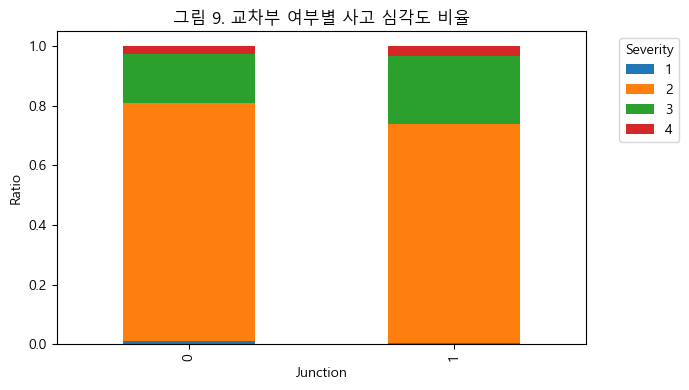

In [25]:
junction_severity = pd.crosstab(data["Junction"], data["Severity"], normalize="index")
print("표 6. 교차부 여부별 Severity 비율")
display(junction_severity)

junction_severity.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("그림 9. 교차부 여부별 사고 심각도 비율")
plt.xlabel("Junction")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig09_junction_severity_ratio.png", dpi=200)
plt.show()

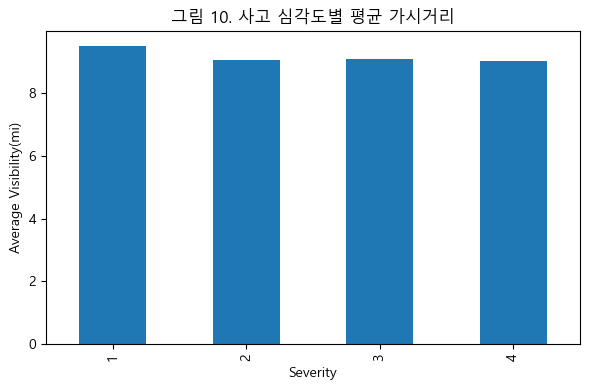

In [26]:
plt.figure(figsize=(6, 4))
data.groupby("Severity")["Visibility(mi)"].mean().plot(kind="bar")
plt.title("그림 10. 사고 심각도별 평균 가시거리")
plt.xlabel("Severity")
plt.ylabel("Average Visibility(mi)")
plt.tight_layout()
plt.savefig("figures/fig10_visibility_by_severity.png", dpi=200)
plt.show()

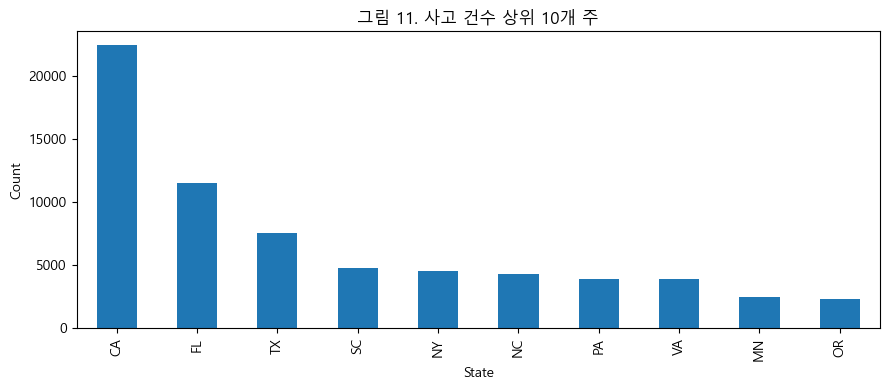

In [27]:
plt.figure(figsize=(9, 4))
data["State"].value_counts().head(10).plot(kind="bar")
plt.title("그림 11. 사고 건수 상위 10개 주")
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig11_top10_states.png", dpi=200)
plt.show()

표 7. 도로환경 변수별 True 비율


Traffic_Signal     0.14762
Crossing           0.11293
Junction           0.07380
Stop               0.02792
Station            0.02593
Amenity            0.01261
Railway            0.00855
Give_Way           0.00502
No_Exit            0.00270
Traffic_Calming    0.00090
Bump               0.00035
Roundabout         0.00002
Turning_Loop       0.00000
dtype: float64

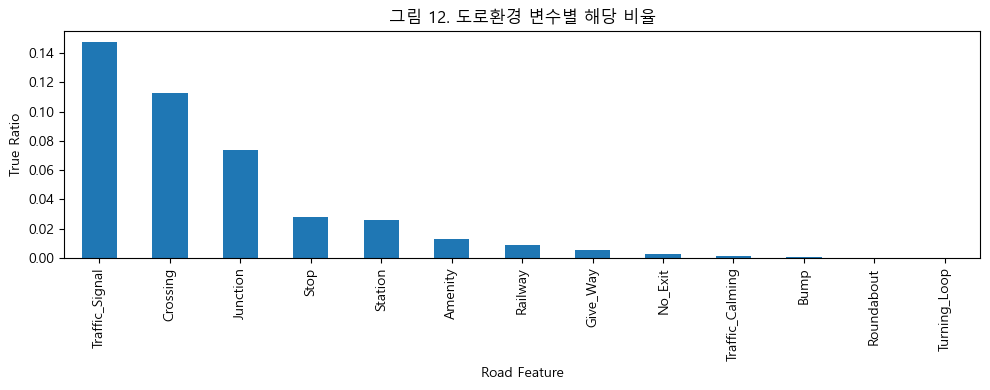

In [28]:
road_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

road_ratio = data[road_cols].mean().sort_values(ascending=False)
print("표 7. 도로환경 변수별 True 비율")
display(road_ratio)

plt.figure(figsize=(10, 4))
road_ratio.plot(kind="bar")
plt.title("그림 12. 도로환경 변수별 해당 비율")
plt.xlabel("Road Feature")
plt.ylabel("True Ratio")
plt.tight_layout()
plt.savefig("figures/fig12_road_feature_ratio.png", dpi=200)
plt.show()

## 15. 입력 데이터와 타깃 데이터 분리

`Severity`는 예측 대상이므로 타깃 데이터로 분리하고, 나머지 변수는 입력 데이터로 사용한다.

In [29]:
input_data = data.drop(columns=["Severity"])
target = data["Severity"]

print("입력 데이터 크기:", input_data.shape)
print("타깃 데이터 크기:", target.shape)
display(target.value_counts(normalize=True).sort_index())

입력 데이터 크기: (100000, 37)
타깃 데이터 크기: (100000,)


Severity
1    0.00872
2    0.79667
3    0.16812
4    0.02649
Name: proportion, dtype: float64

## 16. Train / Validation / Test 분할

모든 모델은 동일한 데이터 분할을 사용한다.

- Train: 모델 학습
- Validation: 모델 비교 및 선택
- Test: 최종 평가

클래스 비율 유지를 위해 `stratify`를 적용한다.

In [30]:
train_input, test_input, train_target, test_target = train_test_split(
    input_data,
    target,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=target
)

train_input, val_input, train_target, val_target = train_test_split(
    train_input,
    train_target,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=train_target
)

print("train:", train_input.shape, train_target.shape)
print("validation:", val_input.shape, val_target.shape)
print("test:", test_input.shape, test_target.shape)

split_ratio = pd.DataFrame({
    "train": train_target.value_counts(normalize=True).sort_index(),
    "validation": val_target.value_counts(normalize=True).sort_index(),
    "test": test_target.value_counts(normalize=True).sort_index()
})

print("표 8. 데이터 분할별 Severity 비율")
display(split_ratio)

train: (69997, 37) (69997,)
validation: (15003, 37) (15003,)
test: (15000, 37) (15000,)
표 8. 데이터 분할별 Severity 비율


,train,validation,test
Severity,,,
1,0.008715,0.008732,0.008733
2,0.796677,0.796641,0.796667
3,0.168121,0.168100,0.168133
4,0.026487,0.026528,0.026467


## 17. 결측치 처리

결측치는 훈련 세트 기준으로 처리한다.

- 수치형 변수: 훈련 세트의 중앙값으로 대체
- 범주형 변수: 훈련 세트의 최빈값으로 대체

검증 세트와 테스트 세트에는 훈련 세트에서 계산한 값을 그대로 적용한다.

In [31]:
train_input = train_input.copy()
val_input = val_input.copy()
test_input = test_input.copy()

num_cols = train_input.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train_input.select_dtypes(include=["object"]).columns.tolist()

print("수치형 변수 수:", len(num_cols))
print("범주형 변수 수:", len(cat_cols))

num_median = train_input[num_cols].median()

train_input[num_cols] = train_input[num_cols].fillna(num_median)
val_input[num_cols] = val_input[num_cols].fillna(num_median)
test_input[num_cols] = test_input[num_cols].fillna(num_median)

cat_mode = train_input[cat_cols].mode().iloc[0]

train_input[cat_cols] = train_input[cat_cols].fillna(cat_mode)
val_input[cat_cols] = val_input[cat_cols].fillna(cat_mode)
test_input[cat_cols] = test_input[cat_cols].fillna(cat_mode)

print("train 결측치 수:", train_input.isnull().sum().sum())
print("validation 결측치 수:", val_input.isnull().sum().sum())
print("test 결측치 수:", test_input.isnull().sum().sum())

수치형 변수 수: 13
범주형 변수 수: 10
train 결측치 수: 0
validation 결측치 수: 0
test 결측치 수: 0


## 18. 범주형 변수 인코딩

범주형 변수는 문자열 그대로 모델에 입력할 수 없기 때문에 `pd.get_dummies()`로 원-핫 인코딩한다.  
검증 세트와 테스트 세트는 훈련 세트와 동일한 열 구조가 되도록 맞춘다.

In [32]:
train_encoded = pd.get_dummies(train_input, columns=cat_cols)
val_encoded = pd.get_dummies(val_input, columns=cat_cols)
test_encoded = pd.get_dummies(test_input, columns=cat_cols)

val_encoded = val_encoded.reindex(columns=train_encoded.columns, fill_value=0)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

print("train_encoded:", train_encoded.shape)
print("val_encoded:", val_encoded.shape)
print("test_encoded:", test_encoded.shape)

train_encoded: (69997, 181)
val_encoded: (15003, 181)
test_encoded: (15000, 181)


## 19. 표준화

로지스틱 회귀와 같은 선형 모델은 변수의 스케일 영향을 받을 수 있으므로 수치형 변수에 `StandardScaler`를 적용한다.  
`StandardScaler`는 훈련 세트에만 `fit()`하고, 검증 세트와 테스트 세트에는 `transform()`만 적용한다.

In [33]:
scaler = StandardScaler()

train_scaled = train_encoded.copy()
val_scaled = val_encoded.copy()
test_scaled = test_encoded.copy()

scaler.fit(train_scaled[num_cols])

train_scaled[num_cols] = scaler.transform(train_scaled[num_cols])
val_scaled[num_cols] = scaler.transform(val_scaled[num_cols])
test_scaled[num_cols] = scaler.transform(test_scaled[num_cols])

display(train_scaled.head())

,Start_Lat,Start_Lng,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Year,Month,DayOfWeek,Hour,Precipitation_NA,City_Atlanta,City_Austin,City_Baton Rouge,City_Charlotte,City_Chicago,City_Columbia,City_Dallas,City_Denver,City_Greenville,City_Houston,City_Indianapolis,City_Jacksonville,City_Los Angeles,City_Miami,City_Minneapolis,City_Nashville,City_Oklahoma City,City_Orlando,City_Other,City_Phoenix,City_Portland,City_Raleigh,City_Richmond,City_Sacramento,City_Saint Paul,City_San Antonio,City_San Diego,City_San Jose,City_Seattle,City_Tampa,City_Tucson,County_Alameda,County_Broward,...,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Timezone_US/Central,Timezone_US/Eastern,Timezone_US/Mountain,Timezone_US/Pacific,Wind_Direction_CALM,Wind_Direction_Calm,Wind_Direction_E,Wind_Direction_ENE,Wind_Direction_ESE,Wind_Direction_East,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,Sunrise_Sunset_Day,Sunrise_Sunset_Night,Civil_Twilight_Day,Civil_Twilight_Night,Nautical_Twilight_Day,Nautical_Twilight_Night,Astronomical_Twilight_Day,Astronomical_Twilight_Night,Weather_Group_Clear,Weather_Group_Cloudy,Weather_Group_Fog,Weather_Group_Other,Weather_Group_Rain,Weather_Group_Snow,Weather_Group_Unknown
92443,0.547090,-1.605585,-0.412499,-0.271223,0.804758,-0.089914,0.331431,-0.518517,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.401169,1.512587,0.814167,0.897313,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,True,False,True,False,False,False,False,False,False
29333,0.513693,-0.582029,-1.639621,-1.706734,0.316933,0.732608,0.331431,-0.596890,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.513009,0.932708,-1.525894,0.128584,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,True,False,False,False,False,False,False,True,False
87792,-0.534955,-1.000920,0.915555,1.019705,-2.210888,-0.823248,0.331431,-0.322584,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,0.710671,-0.516988,0.814167,-0.832328,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False
74620,-0.665896,-0.116431,1.553021,1.639350,-0.570022,0.048824,0.331431,-1.498178,-0

## 20. 평가 함수 정의

본 데이터는 클래스 불균형이 있으므로 Accuracy만 사용하지 않고 여러 지표를 함께 사용한다.

- Accuracy
- Balanced Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

최종 모델은 Validation set의 Macro F1을 기준으로 선택한다.

In [34]:
# 모든 후보 모델과 Validation 결과를 한 곳에 저장한다.
# 이렇게 해야 하이퍼파라미터 실험, class_weight 모델, XGBoost/LightGBM까지
# 최종 모델 선정 과정에 모두 포함할 수 있다.
candidate_models = {}
candidate_val_predictions = {}
candidate_val_results = []
model_label_offset = {}


def get_scores(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def register_model(model_name, model, pred, score, label_offset=0):
    """후보 모델, 예측값, 평가 결과를 최종 비교용 저장소에 등록한다."""
    candidate_models[model_name] = model
    candidate_val_predictions[model_name] = pred
    candidate_val_results.append(score)
    model_label_offset[model_name] = label_offset


def fit_and_eval(model, model_name, label_offset=0):
    model.fit(train_scaled, train_target)
    pred = model.predict(val_scaled)
    if label_offset != 0:
        pred = pred + label_offset
    score = get_scores(model_name, val_target, pred)
    register_model(model_name, model, pred, score, label_offset=label_offset)
    return model, pred, score

## 21. 기준 모델: Dummy Classifier

가장 많은 클래스를 계속 예측하는 기준 모델이다.  
이 모델과 비교하여 실제 머신러닝 모델이 의미 있는 성능 향상을 보였는지 확인한다.

In [35]:
dummy = DummyClassifier(strategy="most_frequent")
dummy, dummy_pred, dummy_result = fit_and_eval(dummy, "Dummy")
print("표 9. Dummy 모델 Validation 결과")
display(pd.DataFrame([dummy_result]))

표 9. Dummy 모델 Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Dummy,0.796641,0.25,0.19916,0.25,0.221703,0.70647


## 22. Logistic Regression

로지스틱 회귀는 기본적인 선형 분류 모델이다.  
본 프로젝트에서는 비교 기준이 되는 기본 모델 중 하나로 사용하였다.

In [36]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr, lr_pred, lr_result = fit_and_eval(lr, "Logistic Regression")
print("표 10. Logistic Regression Validation 결과")
display(pd.DataFrame([lr_result]))

표 10. Logistic Regression Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.801706,0.286219,0.458555,0.286219,0.287859,0.750974


## 23. Decision Tree

결정 트리는 조건을 기준으로 데이터를 분할하는 트리 기반 모델이다.  
과적합을 줄이기 위해 `max_depth=10`으로 제한하였다.

In [37]:
dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt, dt_pred, dt_result = fit_and_eval(dt, "Decision Tree")
print("표 11. Decision Tree Validation 결과")
display(pd.DataFrame([dt_result]))

표 11. Decision Tree Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Decision Tree,0.806039,0.325161,0.51618,0.325161,0.35046,0.762932


## 23-1. 클래스 불균형 대응 추가 모델: Logistic Regression / Decision Tree

`Severity=2`가 다수 클래스이므로 `class_weight="balanced"`를 적용한 모델을 추가로 실험한다.  
이는 소수 클래스인 Severity 1, 3, 4가 학습 과정에서 과도하게 무시되는 문제를 줄이기 위한 방법이다.

In [38]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_balanced, lr_balanced_pred, lr_balanced_result = fit_and_eval(
    lr_balanced,
    "Logistic Regression Balanced"
)

print("표 11-1. Logistic Regression Balanced Validation 결과")
display(pd.DataFrame([lr_balanced_result]))


dt_balanced = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_balanced, dt_balanced_pred, dt_balanced_result = fit_and_eval(
    dt_balanced,
    "Decision Tree Balanced"
)

print("표 11-2. Decision Tree Balanced Validation 결과")
display(pd.DataFrame([dt_balanced_result]))

표 11-1. Logistic Regression Balanced Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression Balanced,0.441312,0.560746,0.346867,0.560746,0.299463,0.530696


표 11-2. Decision Tree Balanced Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Decision Tree Balanced,0.488102,0.603862,0.357887,0.603862,0.333467,0.574697


## 24. Random Forest

랜덤 포레스트는 여러 개의 결정 트리를 사용하는 앙상블 모델이다.

In [39]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf, rf_pred, rf_result = fit_and_eval(rf, "Random Forest")
print("표 12. Random Forest Validation 결과")
display(pd.DataFrame([rf_result]))

표 12. Random Forest Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Random Forest,0.811838,0.289515,0.619796,0.289515,0.294493,0.755224


## 25. 클래스 불균형을 고려한 Random Forest

`class_weight="balanced_subsample"`을 적용하여 소수 클래스가 학습 과정에서 덜 무시되도록 한다.

In [40]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_balanced, rf_balanced_pred, rf_balanced_result = fit_and_eval(
    rf_balanced,
    "Random Forest Balanced"
)

print("표 13. Random Forest Balanced Validation 결과")
display(pd.DataFrame([rf_balanced_result]))

표 13. Random Forest Balanced Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818


## 26. HistGradientBoosting

HistGradientBoosting은 부스팅 기반의 트리 모델이다.  
랜덤 포레스트와 비교하기 위해 사용하였다.

In [41]:
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=RANDOM_STATE
)

hgb, hgb_pred, hgb_result = fit_and_eval(hgb, "HistGradientBoosting")
print("표 14. HistGradientBoosting Validation 결과")
display(pd.DataFrame([hgb_result]))

표 14. HistGradientBoosting Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.78789


## 26-1. 클래스 가중치 기반 HistGradientBoosting 추가 실험

`HistGradientBoostingClassifier`는 `class_weight` 인자를 직접 사용하는 대신, 학습 시 `sample_weight`를 적용하여 클래스 불균형을 완화한다.

In [42]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight_balanced = compute_sample_weight(
    class_weight="balanced",
    y=train_target
)

hgb_weighted = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=RANDOM_STATE
)

hgb_weighted.fit(train_scaled, train_target, sample_weight=sample_weight_balanced)
hgb_weighted_pred = hgb_weighted.predict(val_scaled)
hgb_weighted_result = get_scores("HistGradientBoosting Weighted", val_target, hgb_weighted_pred)
register_model("HistGradientBoosting Weighted", hgb_weighted, hgb_weighted_pred, hgb_weighted_result)

print("표 14-1. HistGradientBoosting Weighted Validation 결과")
display(pd.DataFrame([hgb_weighted_result]))

표 14-1. HistGradientBoosting Weighted Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,HistGradientBoosting Weighted,0.599547,0.654729,0.386803,0.654729,0.396618,0.663783


## 26-2. 추가 모델: XGBoost / LightGBM

최적 모델 선정의 설득력을 높이기 위해 부스팅 계열의 대표 모델인 XGBoost와 LightGBM을 추가 실험한다.  
두 라이브러리가 설치되어 있지 않은 환경에서도 노트북 전체 실행이 중단되지 않도록 `try-except`로 처리하였다.

In [43]:
xgb_result = None
lgbm_result = None

try:
    from xgboost import XGBClassifier

    # XGBoost는 클래스 라벨이 0부터 시작하는 형태를 선호하므로 1~4를 0~3으로 변환한다.
    y_train_xgb = train_target - 1

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb.fit(train_scaled, y_train_xgb, sample_weight=sample_weight_balanced)
    xgb_pred = xgb.predict(val_scaled) + 1
    xgb_result = get_scores("XGBoost Weighted", val_target, xgb_pred)
    register_model("XGBoost Weighted", xgb, xgb_pred, xgb_result, label_offset=1)

    print("표 14-2. XGBoost Weighted Validation 결과")
    display(pd.DataFrame([xgb_result]))

except Exception as e:
    print("XGBoost 실험을 건너뜁니다. 사유:", e)


try:
    from lightgbm import LGBMClassifier

    lgbm = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        objective="multiclass",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    lgbm.fit(train_scaled, train_target)
    lgbm_pred = lgbm.predict(val_scaled)
    lgbm_result = get_scores("LightGBM Balanced", val_target, lgbm_pred)
    register_model("LightGBM Balanced", lgbm, lgbm_pred, lgbm_result)

    print("표 14-3. LightGBM Balanced Validation 결과")
    display(pd.DataFrame([lgbm_result]))

except Exception as e:
    print("LightGBM 실험을 건너뜁니다. 사유:", e)

표 14-2. XGBoost Weighted Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,XGBoost Weighted,0.621209,0.65005,0.388537,0.65005,0.402969,0.681495


표 14-3. LightGBM Balanced Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379


## 27. 모델별 Validation 성능 비교

모든 모델을 동일한 Validation set과 동일한 평가 지표로 비교한다.

표 15. 모델별 Validation 성능 비교


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
6,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
10,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379
7,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.787890
9,XGBoost Weighted,0.621209,0.650050,0.388537,0.650050,0.402969,0.681495
8,HistGradientBoosting Weighted,0.599547,0.654729,0.386803,0.654729,0.396618,0.663783
2,Decision Tree,0.806039,0.325161,0.516180,0.325161,0.350460,0.762932
4,Decision Tree Balanced,0.488102,0.603862,0.357887,0.603862,0.333467,0.574697
3,Logistic Regression Balanced,0.441312,0.560746,0.346867,0.560746,0.299463,0.530696
5,Random Forest,0.811838,0.289515,0.619796,0.289515,0.294493,0.755224
1,Logistic Regression,0.801706,0.286219,0.458555,0.286219,0.287859,0.750974


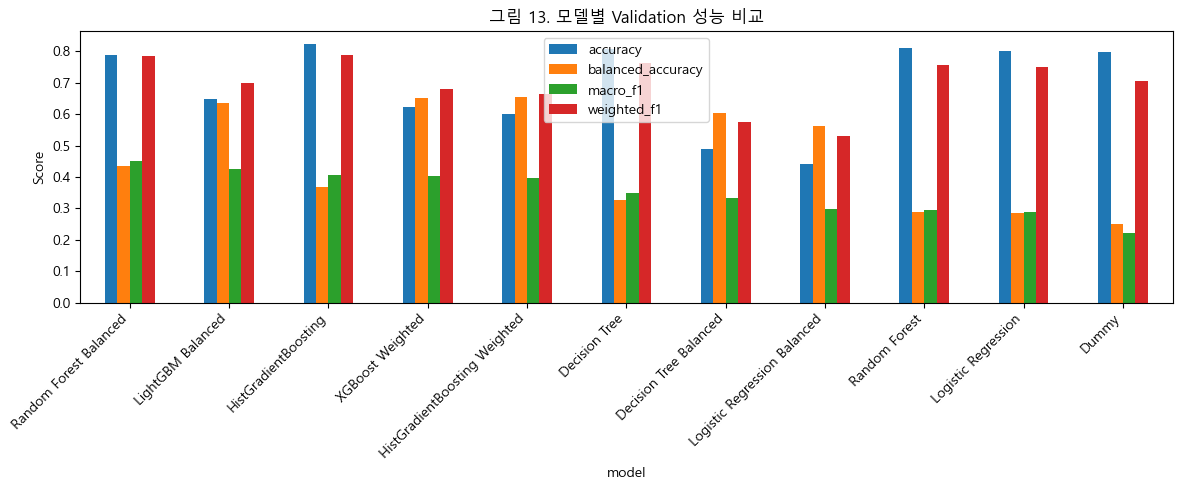

In [44]:
# 지금까지 등록된 모든 후보 모델을 동일한 Validation set 기준으로 비교한다.
# Dummy, 기본 모델, class_weight 적용 모델, 부스팅 추가 모델이 모두 포함된다.
result_df = pd.DataFrame(candidate_val_results).sort_values(by="macro_f1", ascending=False)

print("표 15. 모델별 Validation 성능 비교")
display(result_df)

result_df.to_csv("outputs/model_validation_results.csv", index=False)

result_df.set_index("model")[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]].plot(
    kind="bar",
    figsize=(12, 5)
)
plt.title("그림 13. 모델별 Validation 성능 비교")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/fig13_validation_score_comparison.png", dpi=200)
plt.show()

## 28. 최종 모델 선택 위치 변경 안내

기존에는 이 위치에서 최종 모델을 선택했지만, 이후 하이퍼파라미터 실험과 추가 모델 실험 결과가 반영되지 않는 문제가 있었다.  
따라서 최종 모델 선택과 Test set 평가는 모든 실험이 끝난 뒤 수행한다.

In [45]:
print("최종 모델 선택은 모든 후보 모델 실험이 끝난 뒤 수행합니다.")
display(result_df.head())

최종 모델 선택은 모든 후보 모델 실험이 끝난 뒤 수행합니다.


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
6,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
10,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379
7,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.787890
9,XGBoost Weighted,0.621209,0.650050,0.388537,0.650050,0.402969,0.681495
8,HistGradientBoosting Weighted,0.599547,0.654729,0.386803,0.654729,0.396618,0.663783


## 29. Test set 최종 평가는 뒤에서 수행

Validation 기준 최종 후보가 모두 정리된 후 Test set으로 최종 평가한다.

In [46]:
print("아직 Test set 평가는 수행하지 않습니다. 모든 후보 모델 비교 후 뒤에서 최종 평가합니다.")

아직 Test set 평가는 수행하지 않습니다. 모든 후보 모델 비교 후 뒤에서 최종 평가합니다.


## 30. Confusion Matrix는 최종 모델 선정 후 생성

최종 모델이 확정된 뒤 Confusion Matrix를 생성한다.

In [47]:
print("Confusion Matrix는 최종 모델 선정 후 뒤에서 생성합니다.")

Confusion Matrix는 최종 모델 선정 후 뒤에서 생성합니다.


## 31. Feature Importance는 최종 모델 선정 후 생성

최종 모델이 변수 중요도를 제공하는 모델인 경우 마지막 단계에서 변수 중요도를 출력한다.

In [48]:
print("Feature Importance는 최종 모델 선정 후 뒤에서 생성합니다.")

Feature Importance는 최종 모델 선정 후 뒤에서 생성합니다.


## 32. 하이퍼파라미터 실험: Random Forest max_depth

Random Forest의 `max_depth` 값을 변경하면서 Validation 성능 변화를 확인한다.  
이를 통해 과소적합, 과적합, 모델 선택 이유를 설명할 수 있다.

표 18. Random Forest max_depth 변화에 따른 Validation 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced max_depth=5,0.322136,0.538013,0.334026,0.538013,0.244090,0.396582
1,RF Balanced max_depth=10,0.526295,0.584012,0.356154,0.584012,0.337716,0.604970
2,RF Balanced max_depth=15,0.676265,0.548012,0.384578,0.548012,0.410641,0.717435
3,RF Balanced max_depth=20,0.754916,0.496574,0.444476,0.496574,0.463997,0.767760
4,RF Balanced max_depth=None,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818


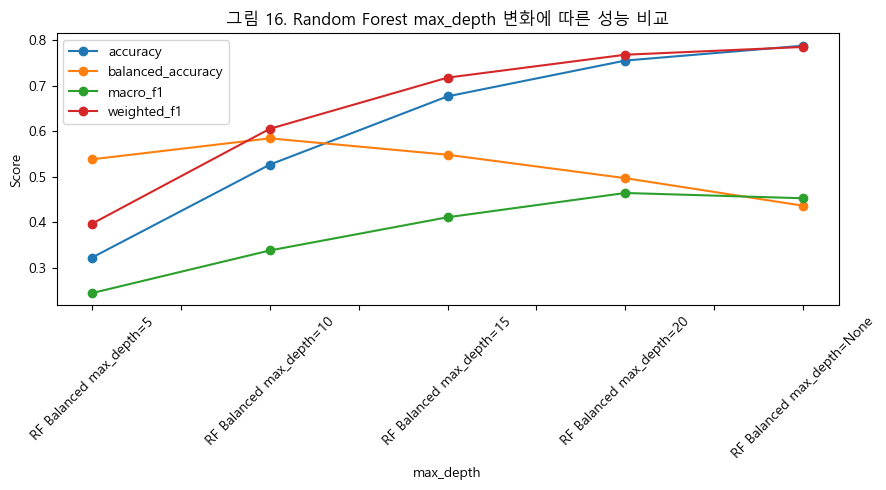

In [49]:
depth_results = []

for depth in [5, 10, 15, 20, None]:
    depth_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    depth_model.fit(train_scaled, train_target)
    depth_pred = depth_model.predict(val_scaled)

    depth_name = "None" if depth is None else str(depth)
    model_name = "RF Balanced max_depth=" + depth_name
    depth_score = get_scores(model_name, val_target, depth_pred)
    depth_results.append(depth_score)

    # 하이퍼파라미터 실험 모델도 최종 후보에 포함한다.
    register_model(model_name, depth_model, depth_pred, depth_score)

depth_df = pd.DataFrame(depth_results)

print("표 18. Random Forest max_depth 변화에 따른 Validation 성능")
display(depth_df)

depth_df.to_csv("outputs/rf_depth_results.csv", index=False)

depth_df.plot(
    x="model",
    y=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
    marker="o",
    figsize=(9, 5)
)
plt.title("그림 16. Random Forest max_depth 변화에 따른 성능 비교")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/fig16_rf_depth_comparison.png", dpi=200)
plt.show()

## 32-1. 하이퍼파라미터 추가 실험: Random Forest min_samples_leaf

`max_depth` 외에도 `min_samples_leaf` 값을 변경하여 리프 노드에 필요한 최소 샘플 수가 성능에 미치는 영향을 확인한다.  
클래스 불균형을 고려하기 위해 `class_weight="balanced_subsample"`은 동일하게 유지한다.


표 18-1. Random Forest min_samples_leaf 변화에 따른 Validation 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=1,0.809171,0.289669,0.613923,0.289669,0.296157,0.751638
1,RF Balanced min_samples_leaf=3,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
2,RF Balanced min_samples_leaf=5,0.767846,0.497007,0.474465,0.497007,0.479013,0.776751
3,RF Balanced min_samples_leaf=10,0.714590,0.543113,0.407556,0.543113,0.441901,0.742402


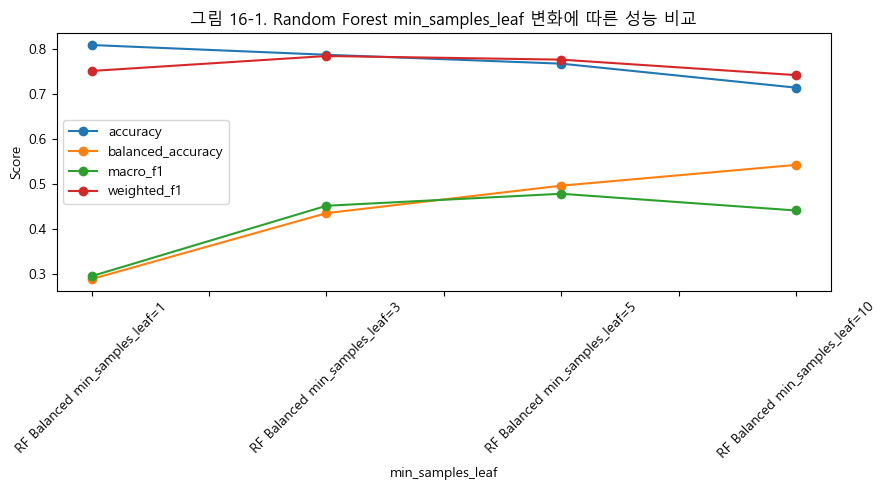

In [50]:
leaf_results = []

for leaf in [1, 3, 5, 10]:
    leaf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=leaf,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    leaf_model.fit(train_scaled, train_target)
    leaf_pred = leaf_model.predict(val_scaled)

    model_name = f"RF Balanced min_samples_leaf={leaf}"
    leaf_score = get_scores(model_name, val_target, leaf_pred)
    leaf_results.append(leaf_score)

    # 하이퍼파라미터 실험 모델도 최종 후보에 포함한다.
    register_model(model_name, leaf_model, leaf_pred, leaf_score)

leaf_df = pd.DataFrame(leaf_results)

print("표 18-1. Random Forest min_samples_leaf 변화에 따른 Validation 성능")
display(leaf_df)

leaf_df.to_csv("outputs/rf_leaf_results.csv", index=False)

leaf_df.plot(
    x="model",
    y=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
    marker="o",
    figsize=(9, 5)
)
plt.title("그림 16-1. Random Forest min_samples_leaf 변화에 따른 성능 비교")
plt.xlabel("min_samples_leaf")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/fig16_1_rf_leaf_comparison.png", dpi=200)
plt.show()

## 33. 추가 실험: Simple Dense Neural Network

선택 과제에 해당하는 간단한 딥러닝 모델을 실험한다.  
다중분류 문제이므로 출력층은 4개 뉴런을 사용하고, 활성화 함수는 `softmax`를 사용한다.

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7746 - loss: 0.6348 - val_accuracy: 0.7990 - val_loss: 0.5315
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7991 - loss: 0.5406 - val_accuracy: 0.8026 - val_loss: 0.5169
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8028 - loss: 0.5254 - val_accuracy: 0.8058 - val_loss: 0.5088
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8047 - loss: 0.5187 - val_accuracy: 0.8068 - val_loss: 0.5048
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8055 - loss: 0.5112 - val_accuracy: 0.8070 - val_loss: 0.5021
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8078 - loss: 0.5080 - val_accuracy: 0.8068 - val_loss: 0.5004
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8080 - loss: 0.5036 - val_accuracy: 0.8072 - val_loss: 0.4987
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8091 - loss: 0.5023 - val_accuracy: 0.

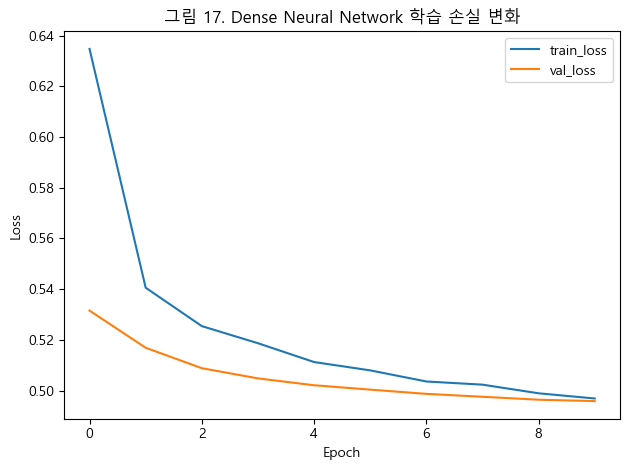

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
표 19. Simple Dense Neural Network Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Simple Dense NN,0.808172,0.291082,0.348456,0.291082,0.294247,0.758426


In [51]:
nn_result = None

try:
    import tensorflow as tf
    from tensorflow import keras

    keras.utils.set_random_seed(RANDOM_STATE)

    y_train_nn = train_target.values - 1
    y_val_nn = val_target.values - 1
    y_test_nn = test_target.values - 1

    X_train_nn = train_scaled.astype("float32").values
    X_val_nn = val_scaled.astype("float32").values
    X_test_nn = test_scaled.astype("float32").values

    nn_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_nn.shape[1],)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(4, activation="softmax")
    ])

    nn_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = nn_model.fit(
        X_train_nn,
        y_train_nn,
        epochs=10,
        batch_size=256,
        validation_data=(X_val_nn, y_val_nn),
        verbose=1
    )

    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("그림 17. Dense Neural Network 학습 손실 변화")
    plt.tight_layout()
    plt.savefig("figures/fig17_nn_loss.png", dpi=200)
    plt.show()

    nn_val_pred = np.argmax(nn_model.predict(X_val_nn), axis=1) + 1
    nn_result = get_scores("Simple Dense NN", val_target, nn_val_pred)

    print("표 19. Simple Dense Neural Network Validation 결과")
    display(pd.DataFrame([nn_result]))
    pd.DataFrame([nn_result]).to_csv("outputs/nn_validation_result.csv", index=False)

except Exception as e:
    print("딥러닝 추가 실험 실행 중 오류 발생")
    print(e)


## 34. 전체 Validation 결과 통합 비교

기존 머신러닝 모델 비교표에 Simple Dense Neural Network 결과가 존재하면 함께 추가한다.  
단, 최종 모델 선정은 앞에서 산출한 Validation 성능 기준을 유지하며, 딥러닝 모델은 추가 실험 결과로 비교한다.


표 19-1. 전체 모델 Validation 성능 통합 비교


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
18,RF Balanced min_samples_leaf=5,0.767846,0.497007,0.474465,0.497007,0.479013,0.776751
14,RF Balanced max_depth=20,0.754916,0.496574,0.444476,0.496574,0.463997,0.767760
15,RF Balanced max_depth=None,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
6,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
17,RF Balanced min_samples_leaf=3,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
19,RF Balanced min_samples_leaf=10,0.714590,0.543113,0.407556,0.543113,0.441901,0.742402
10,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379
13,RF Balanced max_depth=15,0.676265,0.548012,0.384578,0.548012,0.410641,0.717435
7,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.787890
9,XGBoost Weighted,0.621209,0.650050,0.388537,0.650050,0.402969,0.681495


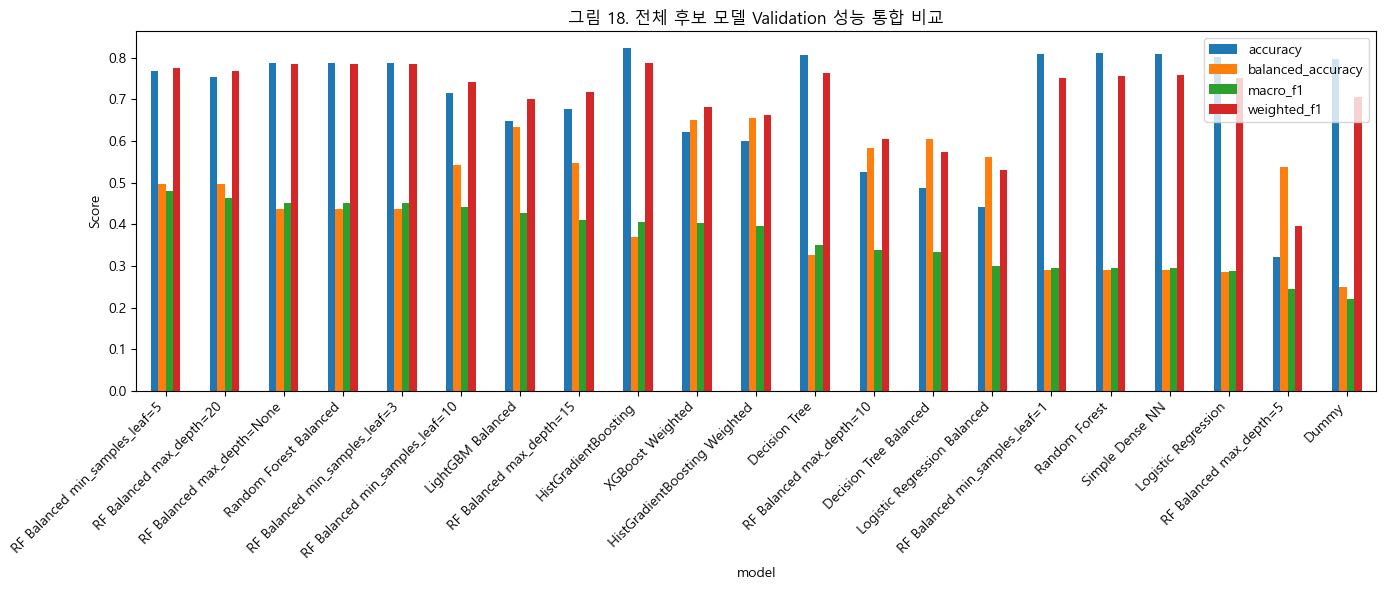

In [52]:
# 모든 후보 모델 결과를 최종 통합 비교표에 포함한다.
# 여기에는 기본 모델, class_weight 모델, XGBoost/LightGBM, RF 하이퍼파라미터 실험 결과가 포함된다.
final_validation_results = candidate_val_results.copy()

if nn_result is not None:
    final_validation_results.append(nn_result)
else:
    print("Simple Dense NN 결과가 없어 머신러닝 모델 결과만 통합 비교표에 포함합니다.")

final_result_df = pd.DataFrame(final_validation_results).drop_duplicates(subset=["model"], keep="last")
final_result_df = final_result_df.sort_values(by="macro_f1", ascending=False)

print("표 19-1. 전체 모델 Validation 성능 통합 비교")
display(final_result_df)

final_result_df.to_csv("outputs/model_validation_results_all_candidates.csv", index=False)

final_result_df.set_index("model")[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]].plot(
    kind="bar",
    figsize=(14, 6)
)
plt.title("그림 18. 전체 후보 모델 Validation 성능 통합 비교")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/fig18_all_candidate_validation_comparison.png", dpi=200)
plt.show()

## 35. 최종 모델 선택 및 Test set 평가

모든 후보 모델을 통합 비교한 뒤, Validation set의 `macro_f1`이 가장 높은 모델을 최종 모델로 선정한다.  
`Severity=2`가 다수인 불균형 데이터이므로 단순 Accuracy가 아니라 소수 클래스 성능을 함께 반영하는 `macro_f1`을 기준으로 사용한다.

In [53]:
best_model_name = final_result_df.iloc[0]["model"]

print("최종 선택 모델:", best_model_name)
display(final_result_df.head(10))


def predict_with_final_model(model_name, X):
    """모델 종류에 따라 Test set 예측값을 동일한 Severity 1~4 형태로 반환한다."""
    if model_name == "Simple Dense Neural Network":
        X_nn = X.astype("float32").values
        pred_proba = nn_model.predict(X_nn, verbose=0)
        return np.argmax(pred_proba, axis=1) + 1

    model = candidate_models[model_name]
    pred = model.predict(X)

    # XGBoost는 0~3으로 학습했기 때문에 예측 후 다시 1~4로 변환한다.
    if model_label_offset.get(model_name, 0) != 0:
        pred = pred + model_label_offset[model_name]

    return pred


test_pred = predict_with_final_model(best_model_name, test_scaled)

test_result = get_scores(best_model_name, test_target, test_pred)
test_result_df = pd.DataFrame([test_result])

print("표 20. 최종 모델 Test 성능")
display(test_result_df)

test_result_df.to_csv("outputs/model_test_result.csv", index=False)

print("최종 모델 Classification Report")
print(classification_report(test_target, test_pred, zero_division=0))

per_class_report_df = pd.DataFrame(
    classification_report(test_target, test_pred, output_dict=True, zero_division=0)
).T

print("표 21. 최종 모델 클래스별 성능")
display(per_class_report_df)

per_class_report_df.to_csv("outputs/final_model_classification_report.csv", index=True)

최종 선택 모델: RF Balanced min_samples_leaf=5


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
18,RF Balanced min_samples_leaf=5,0.767846,0.497007,0.474465,0.497007,0.479013,0.776751
14,RF Balanced max_depth=20,0.754916,0.496574,0.444476,0.496574,0.463997,0.767760
15,RF Balanced max_depth=None,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
6,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
17,RF Balanced min_samples_leaf=3,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
19,RF Balanced min_samples_leaf=10,0.714590,0.543113,0.407556,0.543113,0.441901,0.742402
10,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379
13,RF Balanced max_depth=15,0.676265,0.548012,0.384578,0.548012,0.410641,0.717435
7,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.787890
9,XGBoost Weighted,0.621209,0.650050,0.388537,0.650050,0.402969,0.681495


표 20. 최종 모델 Test 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=5,0.761267,0.499084,0.468266,0.499084,0.476525,0.771853


최종 모델 Classification Report
              precision    recall  f1-score   support

           1       0.35      0.42      0.38       131
           2       0.89      0.81      0.85     11950
           3       0.43      0.63      0.51      2522
           4       0.19      0.13      0.16       397

    accuracy                           0.76     15000
   macro avg       0.47      0.50      0.48     15000
weighted avg       0.79      0.76      0.77     15000

표 21. 최종 모델 클래스별 성능


,precision,recall,f1-score,support
1,0.354839,0.419847,0.384615,131.000000
2,0.892601,0.813724,0.851340,11950.000000
3,0.431485,0.629262,0.511935,2522.000000
4,0.194139,0.133501,0.158209,397.000000
accuracy,0.761267,0.761267,0.761267,0.761267
macro avg,0.468266,0.499084,0.476525,15000.000000
weighted avg,0.791890,0.761267,0.771853,15000.000000


## 36. 최종 모델 Confusion Matrix

Confusion Matrix를 통해 다수 클래스인 Severity 2로 예측이 몰리는지, 소수 클래스인 Severity 1, 3, 4가 얼마나 오분류되는지 확인한다.

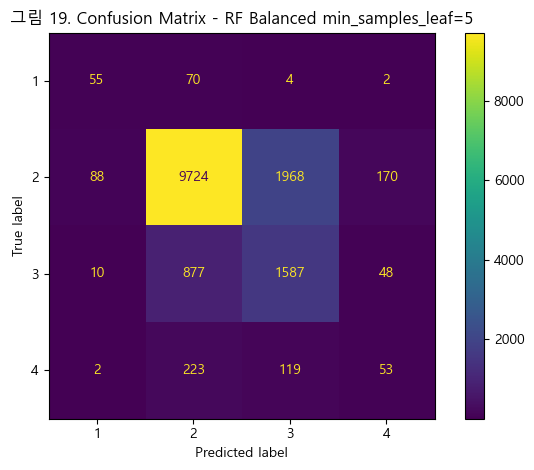

In [54]:
ConfusionMatrixDisplay.from_predictions(test_target, test_pred)
plt.title("그림 19. Confusion Matrix - " + best_model_name)
plt.tight_layout()
plt.savefig("figures/fig19_final_confusion_matrix.png", dpi=200)
plt.show()

## 37. 최종 모델 변수 중요도 또는 계수 확인

최종 모델이 트리 기반 모델이면 `feature_importances_`, 선형 모델이면 `coef_`를 이용해 변수 영향도를 참고용으로 확인한다.  
단, 변수 중요도는 인과관계가 아니라 모델이 예측에 사용한 상대적 정보량을 의미한다.

표 22. 최종 모델 변수 중요도 상위 20개


,feature,importance
22,Year,0.102836
1,Start_Lng,0.068856
0,Start_Lat,0.067439
23,Month,0.061139
3,Wind_Chill(F),0.056536
5,Pressure(in),0.053321
2,Temperature(F),0.051248
25,Hour,0.050966
4,Humidity(%),0.044912
7,Wind_Speed(mph),0.034443


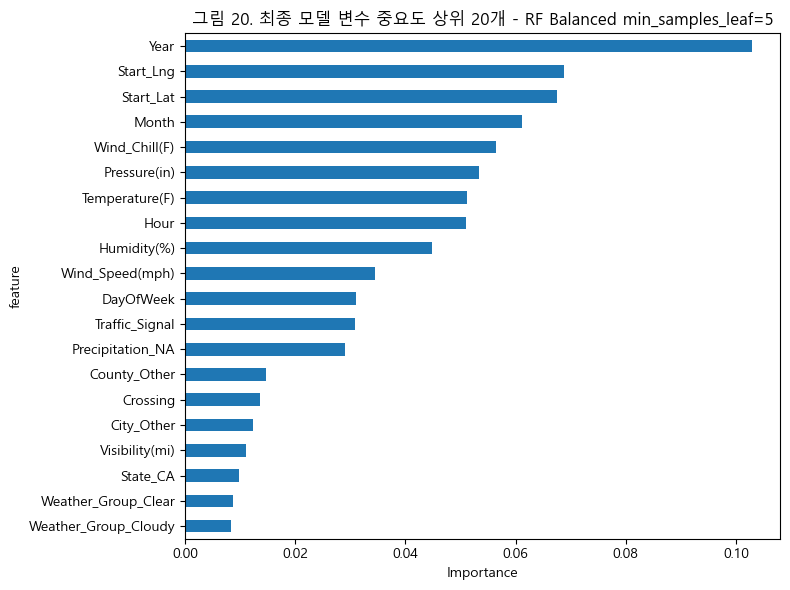

In [55]:
if best_model_name == "Simple Dense Neural Network":
    print("Neural Network는 현재 코드에서 변수 중요도를 직접 출력하지 않습니다.")
else:
    final_model = candidate_models[best_model_name]

    if hasattr(final_model, "feature_importances_"):
        importance_values = final_model.feature_importances_
        importance_df = pd.DataFrame({
            "feature": train_scaled.columns,
            "importance": importance_values
        }).sort_values(by="importance", ascending=False)

    elif hasattr(final_model, "coef_"):
        coef_values = np.mean(np.abs(final_model.coef_), axis=0)
        importance_df = pd.DataFrame({
            "feature": train_scaled.columns,
            "importance": coef_values
        }).sort_values(by="importance", ascending=False)

    else:
        importance_df = None
        print("선택된 모델은 변수 중요도 또는 계수를 제공하지 않습니다:", best_model_name)

    if importance_df is not None:
        print("표 22. 최종 모델 변수 중요도 상위 20개")
        display(importance_df.head(20))
        importance_df.to_csv("outputs/final_model_feature_importance.csv", index=False)

        importance_df.head(20).sort_values("importance").plot(
            x="feature",
            y="importance",
            kind="barh",
            figsize=(8, 6),
            legend=False
        )
        plt.title("그림 20. 최종 모델 변수 중요도 상위 20개 - " + best_model_name)
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.savefig("figures/fig20_final_feature_importance.png", dpi=200)
        plt.show()

## 34. 보고서용 요약

최종 보고서에 사용할 핵심 정보를 출력하고 저장한다.

In [56]:
summary = {
    "original_shape": df.shape,
    "sampled_shape": sampled_df.shape,
    "processed_shape": data.shape,
    "encoded_feature_count": train_scaled.shape[1],
    "train_size": train_scaled.shape[0],
    "validation_size": val_scaled.shape[0],
    "test_size": test_scaled.shape[0],
    "best_model": best_model_name,
    "random_state": RANDOM_STATE,
    "sample_size": SAMPLE_SIZE
}

summary_df = pd.DataFrame([summary])
print("표 20. 최종 보고서 작성용 실험 요약")
display(summary_df)

summary_df.to_csv("outputs/experiment_summary.csv", index=False)

print("Validation 결과")
try:
    display(final_result_df)
except NameError:
    display(result_df)

print("Test 결과")
display(test_result_df)

print("저장된 주요 파일")
print("- outputs/model_validation_results.csv")
print("- outputs/model_validation_results_with_nn.csv")
print("- outputs/model_test_result.csv")
print("- outputs/rf_depth_results.csv")
print("- outputs/rf_leaf_results.csv")
print("- outputs/feature_importance.csv")
print("- figures/*.png")


표 20. 최종 보고서 작성용 실험 요약


,original_shape,sampled_shape,processed_shape,encoded_feature_count,train_size,validation_size,test_size,best_model,random_state,sample_size
0,"(7728394, 34)","(100000, 34)","(100000, 38)",181,69997,15003,15000,RF Balanced min_samples_leaf=5,42,100000


Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
18,RF Balanced min_samples_leaf=5,0.767846,0.497007,0.474465,0.497007,0.479013,0.776751
14,RF Balanced max_depth=20,0.754916,0.496574,0.444476,0.496574,0.463997,0.767760
15,RF Balanced max_depth=None,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
6,Random Forest Balanced,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
17,RF Balanced min_samples_leaf=3,0.787576,0.436034,0.509615,0.436034,0.452392,0.784818
19,RF Balanced min_samples_leaf=10,0.714590,0.543113,0.407556,0.543113,0.441901,0.742402
10,LightGBM Balanced,0.648937,0.634662,0.400018,0.634662,0.426205,0.700379
13,RF Balanced max_depth=15,0.676265,0.548012,0.384578,0.548012,0.410641,0.717435
7,HistGradientBoosting,0.822569,0.369344,0.589043,0.369344,0.406334,0.787890
9,XGBoost Weighted,0.621209,0.650050,0.388537,0.650050,0.402969,0.681495


Test 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=5,0.761267,0.499084,0.468266,0.499084,0.476525,0.771853


저장된 주요 파일
- outputs/model_validation_results.csv
- outputs/model_validation_results_with_nn.csv
- outputs/model_test_result.csv
- outputs/rf_depth_results.csv
- outputs/rf_leaf_results.csv
- outputs/feature_importance.csv
- figures/*.png


## 36. 최종 결론

본 프로젝트에서는 US Accidents 데이터를 활용하여 교통사고 심각도(`Severity`)를 4개 클래스로 분류하였다. 데이터는 `Severity=2` 클래스에 집중된 불균형 구조를 보였기 때문에 단순 정확도(`accuracy`)뿐만 아니라 `balanced accuracy`, `macro F1-score`, `weighted F1-score`를 함께 평가 지표로 사용하였다.

여러 모델을 비교한 결과, Validation set에서 `macro F1-score`가 가장 높은 모델을 최종 모델로 선정하였다. Test set 평가에서도 Validation 결과와 유사한 성능을 보여, 최종 모델이 학습 데이터에만 과도하게 맞춰진 것은 아닌지 확인하였다.

변수 중요도 분석 결과 사고 발생 연도, 위치 정보, 월, 기압, 체감온도, 기온, 시간대 등의 변수가 사고 심각도 예측에 상대적으로 큰 영향을 미치는 것으로 나타났다. 다만 소수 클래스의 예측 성능은 여전히 제한적이므로, 향후에는 SMOTE, class weight 세부 조정, XGBoost/LightGBM 등의 추가 모델을 적용하여 클래스 불균형 문제를 개선할 필요가 있다.


## 37. 최종 체크리스트

제출 전 아래 내용을 확인한다.

- [ ] 노트북이 처음부터 끝까지 실행되는지 확인
- [ ] 원본 CSV 파일이 GitHub에 올라가지 않았는지 확인
- [ ] README.md 포함
- [ ] .gitignore 포함
- [ ] requirements.txt 포함
- [ ] outputs 폴더에 결과표 저장
- [ ] figures 폴더에 그래프 저장
- [ ] 보고서 수치와 노트북 결과가 일치하는지 확인
- [ ] 최종 보고서를 `Report/Submission` 폴더에 제출